# EDA — VALE3.SA
Análise exploratória dos dados históricos de preço de fechamento.

In [40]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='darkgrid')


## 1. Carregar dados brutos

In [41]:
df = pd.read_csv('../data/raw/vale3_raw.csv', index_col=0, parse_dates=True)
print(f'Shape: {df.shape}')
print(f'Período: {df.index.min().date()} → {df.index.max().date()}')
df.head()

Shape: (1626, 5)
Período: 2018-01-02 → 2024-07-19


,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,21.669312,21.679700,21.004480,21.004480,14156500
2018-01-03,21.539463,21.752416,21.451164,21.726447,12744200
2018-01-04,21.627758,22.006919,21.565431,21.716057,18433000
2018-01-05,21.965374,21.965374,21.456363,21.591406,15251300
2018-01-08,22.453604,22.453604,22.022504,22.022504,14542800


In [42]:
print('--- Nulos ---')
print(df.isnull().sum())
print('\n--- Estatísticas ---')
df.describe().round(2)

--- Nulos ---
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

--- Estatísticas ---


,Close,High,Low,Open,Volume
count,1626.00,1626.00,1626.00,1626.00,1.626000e+03
mean,44.05,44.60,43.52,44.09,2.526359e+07
std,15.50,15.66,15.35,15.52,1.272660e+07
min,18.92,19.89,18.00,19.72,0.000000e+00
25%,27.89,28.32,27.63,27.94,1.727245e+07
50%,49.88,50.47,49.37,49.95,2.269190e+07
75%,56.03,56.76,55.30,56.11,3.004652e+07
max,73.03,73.24,71.83,72.91,1.835345e+08


## 2. Série temporal de fechamento

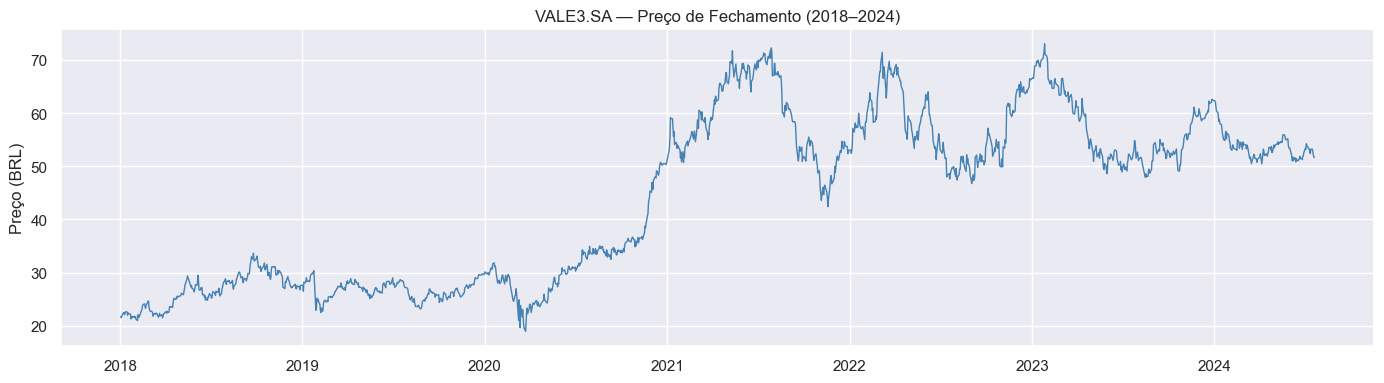

In [43]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['Close'], color='steelblue', linewidth=1)
ax.set_title('VALE3.SA — Preço de Fechamento (2018–2024)')
ax.set_ylabel('Preço (BRL)')
plt.tight_layout()
plt.show()

VALE3 apresentou forte valorização em meados de 2021, provavelmente impulsionada pelos preços do minério de ferro. 
O primeiro pico ocorreu em torno de julho/2021, seguido de correção. Esse padrão ocorre mais duas vezes em 2022 e 2023
e a partir de 2023, o preço estabilizou em uma faixa mais comprimida.

## 3. Volume diário

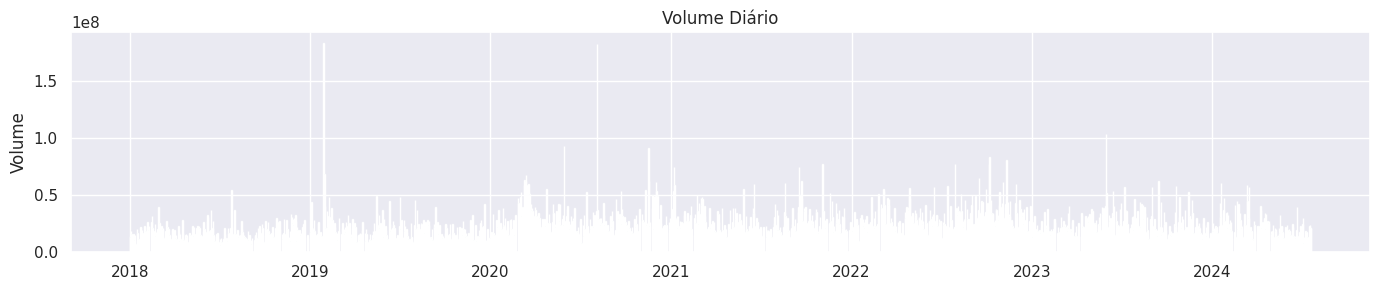

In [44]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(df.index, df['Volume'], color='#2ecc71', width=1)
ax.set_title('Volume Diário')
ax.set_ylabel('Volume')
plt.style.use('default')
plt.tight_layout()
plt.show()

O volume apresenta alta variabilidade ao longo do período, com picos pontuais. Nota-se tendência de maior volume médio a partir de 2020.

## 4. Retornos diários e volatilidade

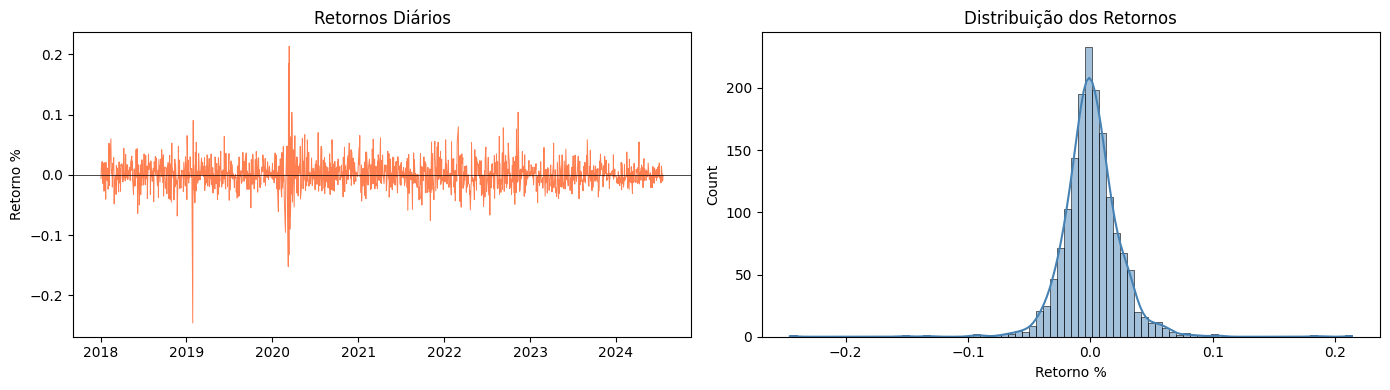

In [45]:
returns = df['Close'].pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(df.index[1:], returns, color='coral', linewidth=0.7)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('Retornos Diários')
axes[0].set_ylabel('Retorno %')

sns.histplot(returns, bins=80, kde=True, color='steelblue', ax=axes[1])
axes[1].set_title('Distribuição dos Retornos')
axes[1].set_xlabel('Retorno %')

plt.tight_layout()
plt.show()

A maior parte do tempo os retornos ficam próximos de zero, indicando ausência de tendência diária consistente (comportamento esperado).
Há picos extremos (outliers). Isso sugere eventos pontuais relevantes (crises, notícias, choques macro, COVID).
Nota-se clusterização de volatilidade: períodos mais “calmos” alternam com fases mais turbulentas. Isso é comum em mercados financeiros e indica que risco não é constante ao longo do tempo.

A distribuição é aproximadamente centrada em zero, como esperado. Porém, apresenta caudas mais longas que uma normal (leptocurtose), ou seja, eventos extremos acontecem com mais frequência do que um modelo normal preveria.
Pode haver leve assimetria (dependendo do ajuste visual), sugerindo que quedas bruscas podem ser mais intensas que altas — algo comum em ações.

## 5. Volatilidade mensal

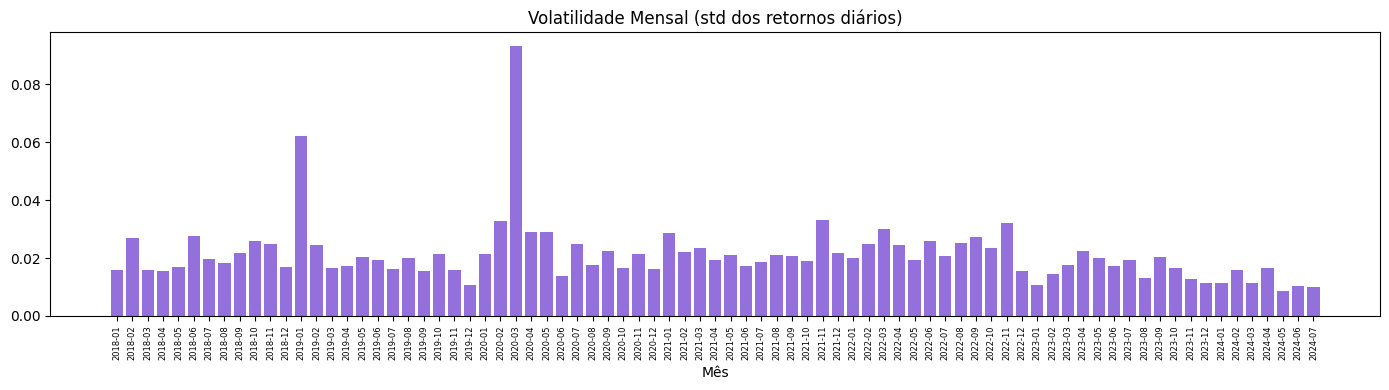

In [46]:
monthly_vol = returns.groupby(returns.index.to_period('M')).std()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly_vol.index.astype(str), monthly_vol.values, color='mediumpurple')
ax.set_title('Volatilidade Mensal (std dos retornos diários)')
ax.set_xlabel('Mês')
ax.tick_params(axis='x', rotation=90, labelsize=6)
plt.tight_layout()
plt.show()

A volatilidade mensal confirma o pico de março/2020 como o mais expressivo da série, associado ao choque da pandemia.
A partir de 2023, a volatilidade mensal recua e se estabiliza.

## 6. Identificação de outliers (|z-score| > 3)

In [47]:
z_scores = (returns - returns.mean()) / returns.std()
outliers = returns[np.abs(z_scores) > 3]
print(f'Total de dias: {len(df)}')
print(f'Outliers (|z|>3): {len(outliers)}')
print(outliers.sort_values())

Total de dias: 1626
Outliers (|z|>3): 16
Date
2019-01-28   -0.245592
2020-03-09   -0.151984
2020-03-12   -0.132302
2020-02-26   -0.095352
2020-03-11   -0.090828
2020-03-16   -0.089977
2021-11-03   -0.075913
2022-11-04    0.075949
2022-09-09    0.078128
2022-03-02    0.079866
2020-03-25    0.085282
2019-01-30    0.090313
2020-03-24    0.103812
2022-11-11    0.103957
2020-03-10    0.184510
2020-03-13    0.213578
Name: Close, dtype: float64


Os dias com |z-score| > 3 representam movimentos extremos associados a eventos como COVID, anúncios de dividendos ou choques abruptos no preço 
do minério de ferro. Esses outliers **não serão removidos**, pois fazem parte da dinâmica real do ativo e o modelo LSTM precisa aprender a lidar com essa volatilidade.

## 7. Verificação de datas ausentes

In [48]:
all_business_days = pd.bdate_range(start=df.index.min(), end=df.index.max())
missing = all_business_days.difference(df.index)
print(f'Dias úteis esperados: {len(all_business_days)}')
print(f'Dias no dataset: {len(df)}')
print(f'Dias ausentes (feriados B3): {len(missing)}')

Dias úteis esperados: 1709
Dias no dataset: 1626
Dias ausentes (feriados B3): 83
